In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

Your Name and PRN:
- Name: ______________________
- PRN : ______________________
- Date: ______________________

# CNN on mnist dataset

In [2]:
###-----------------
### Import Libraries
###-----------------

import os
import numpy as np
import pandas as pd

from collections.abc import Callable
from typing import Literal


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader, Dataset

from tqdm.auto import tqdm

In [3]:
###----------------------
### Some basic parameters
###----------------------
inpDir = os.path.join('dnn_files')
outDir = '../output'
modelDir = '../models'
subDir = 'fashion_mnist'
altName = 'A04_fashion_vanila'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
torch.manual_seed(RANDOM_STATE) # Set Random Seed for reproducible  results

EPOCHS = 75 # number of epochs
BATCH_SIZE = 64
ALPHA = 0.001 # learning rate
NUM_GENERATE = 1000
TEMPERATURE = 0.8
BUFFER_SIZE = 10000
SEQ_LENGTH = 100
EMBEDDING_DIM = 256
RNN_UNITS = 1024
PATIENCE = 10
MIN_DELTA = 1e-4
LR_PATIENCE = 5
LR_FACTOR =0.1
TEST_SIZE = 0.2


# parameters for Matplotlib
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 10),
          'axes.labelsize': 'x-large',
          'axes.titlesize':'x-large',
          'xtick.labelsize':'x-large',
          'ytick.labelsize':'x-large'
         }

CMAP = plt.cm.coolwarm

plt.rcParams.update(params)

## All about CUDA

In [4]:
# print ('Is CUDA available: ', torch.cuda.is_available())

# print ('CUDA version: ', torch.version.cuda )

# print ('Current Device ID: ', torch.cuda.current_device())

# print ('Name of the CUDA device: ', torch.cuda.get_device_name(torch.cuda.current_device()))

In [5]:
# Get cpu or gpu device for training.

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using {device} device")

Using cpu device


# Load MNIST dataset

In [6]:
train_filename = "fashion-mnist_train.csv"
test_filename = "fashion-mnist_test.csv"

train_df = pd.read_csv(train_filename, header=0)
test_df = pd.read_csv(test_filename, header=0)

In [7]:
# class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
#               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

class_names = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot",
}

In [8]:
import sklearn
class DataTransformer:
    def __init__(self):
        self.scaler = sklearn.preprocessing.StandardScaler()
        self.encoder = sklearn.preprocessing.LabelEncoder()
        self.isfit = False
    def fit(self,X,y):
        self.scaler.fit(X)
        self.encoder.fit(y)
        self.isfit = True
    def transform(self,X,y):
        if self.isfit:
            X = self.scaler.transform(X)
            y = self.encoder.transform(y)
            return X,y
        else:
            raise ValueError("transformer is not fitted")
    def fit_transform(self,X,y):
        X = self.scaler.fit_transform(X)
        y = self.encoder.fit_transform(y)
        self.isfit = True
        return X,y

In [9]:
class FashionMNISTDataset(Dataset):
    def __init__(self,dataframe,transform = None):
        super(FashionMNISTDataset, self).__init__()
        self.labels = dataframe.iloc[:,0].to_numpy().astype(np.int64)
        self.images = dataframe.iloc[:,1:].to_numpy().astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.labels)
    def __getitem__(self,index):
        image = self.images[index].reshape(28,28,1)
        image = image/255.0
        label = self.labels[index]
        image = torch.from_numpy(image).permute(2,0,1)
        if self.transform:
            image = self.transform(image)
    
        return image, label

In [10]:
train_dataset = FashionMNISTDataset(train_df)
test_dataset = FashionMNISTDataset(test_df)

In [11]:
train_loader = DataLoader(train_dataset,batch_size = BATCH_SIZE,shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,shuffle =False)

len(train_loader),len(test_loader)

(938, 157)

In [12]:
def show_samples(data_loader,class_labels,num_samples = BATCH_SIZE):
    images,labels = next(iter(data_loader))
    cols =8
    rows = num_samples//8
    fig,axes = plt.subplots(rows,cols,figsize = (15,rows*2))
    axes = axes.ravel()
    for i in range(num_samples):
        img = images[i].squeeze().numpy()
        ax = axes[i]
        ax.imshow(img,cmap = plt.cm.binary)
        ax.set_title(class_labels[labels[i].item()])
        ax.axis("off")
    plt.tight_layout()
    plt.show()

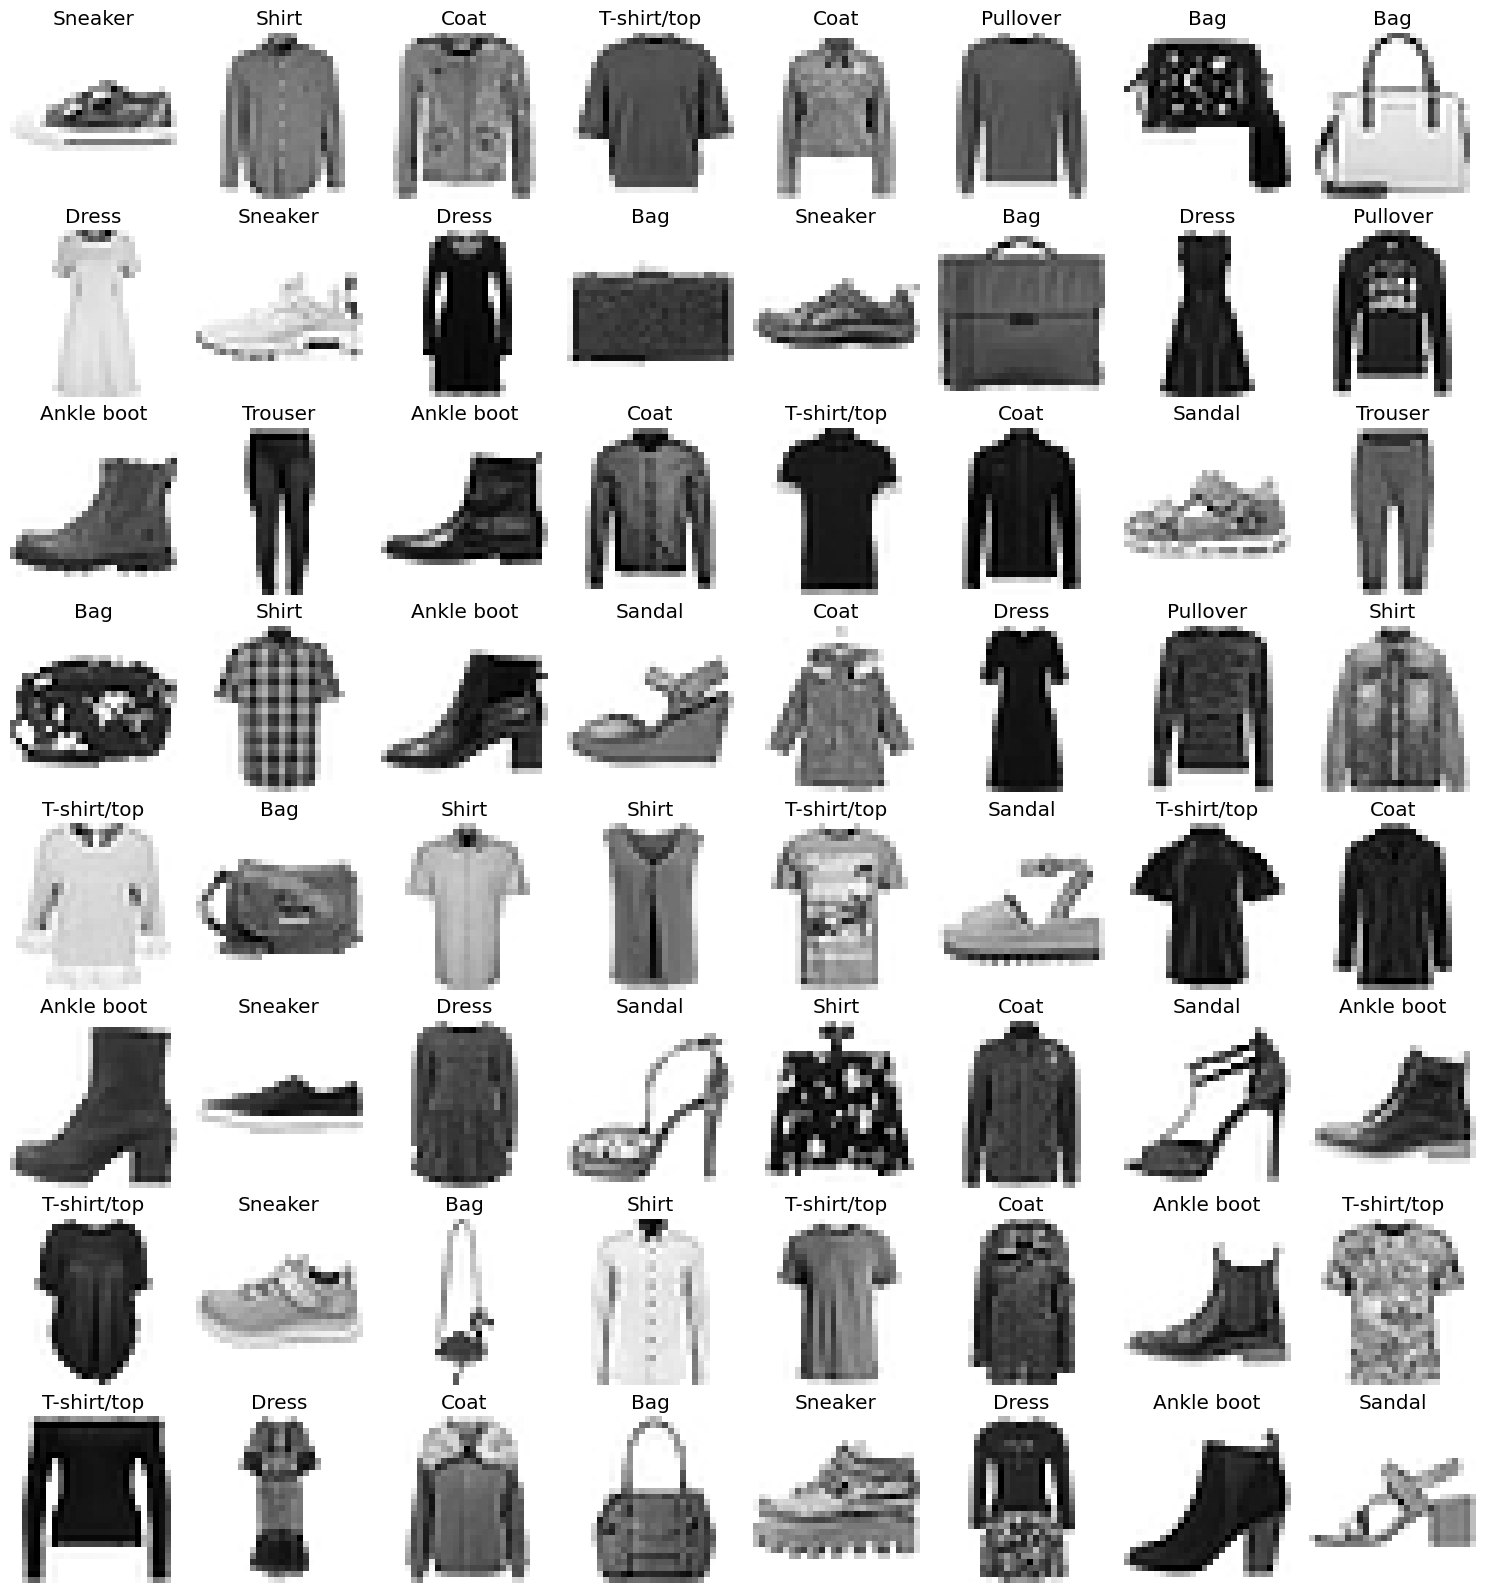

In [13]:
show_samples(train_loader,class_labels=class_names)

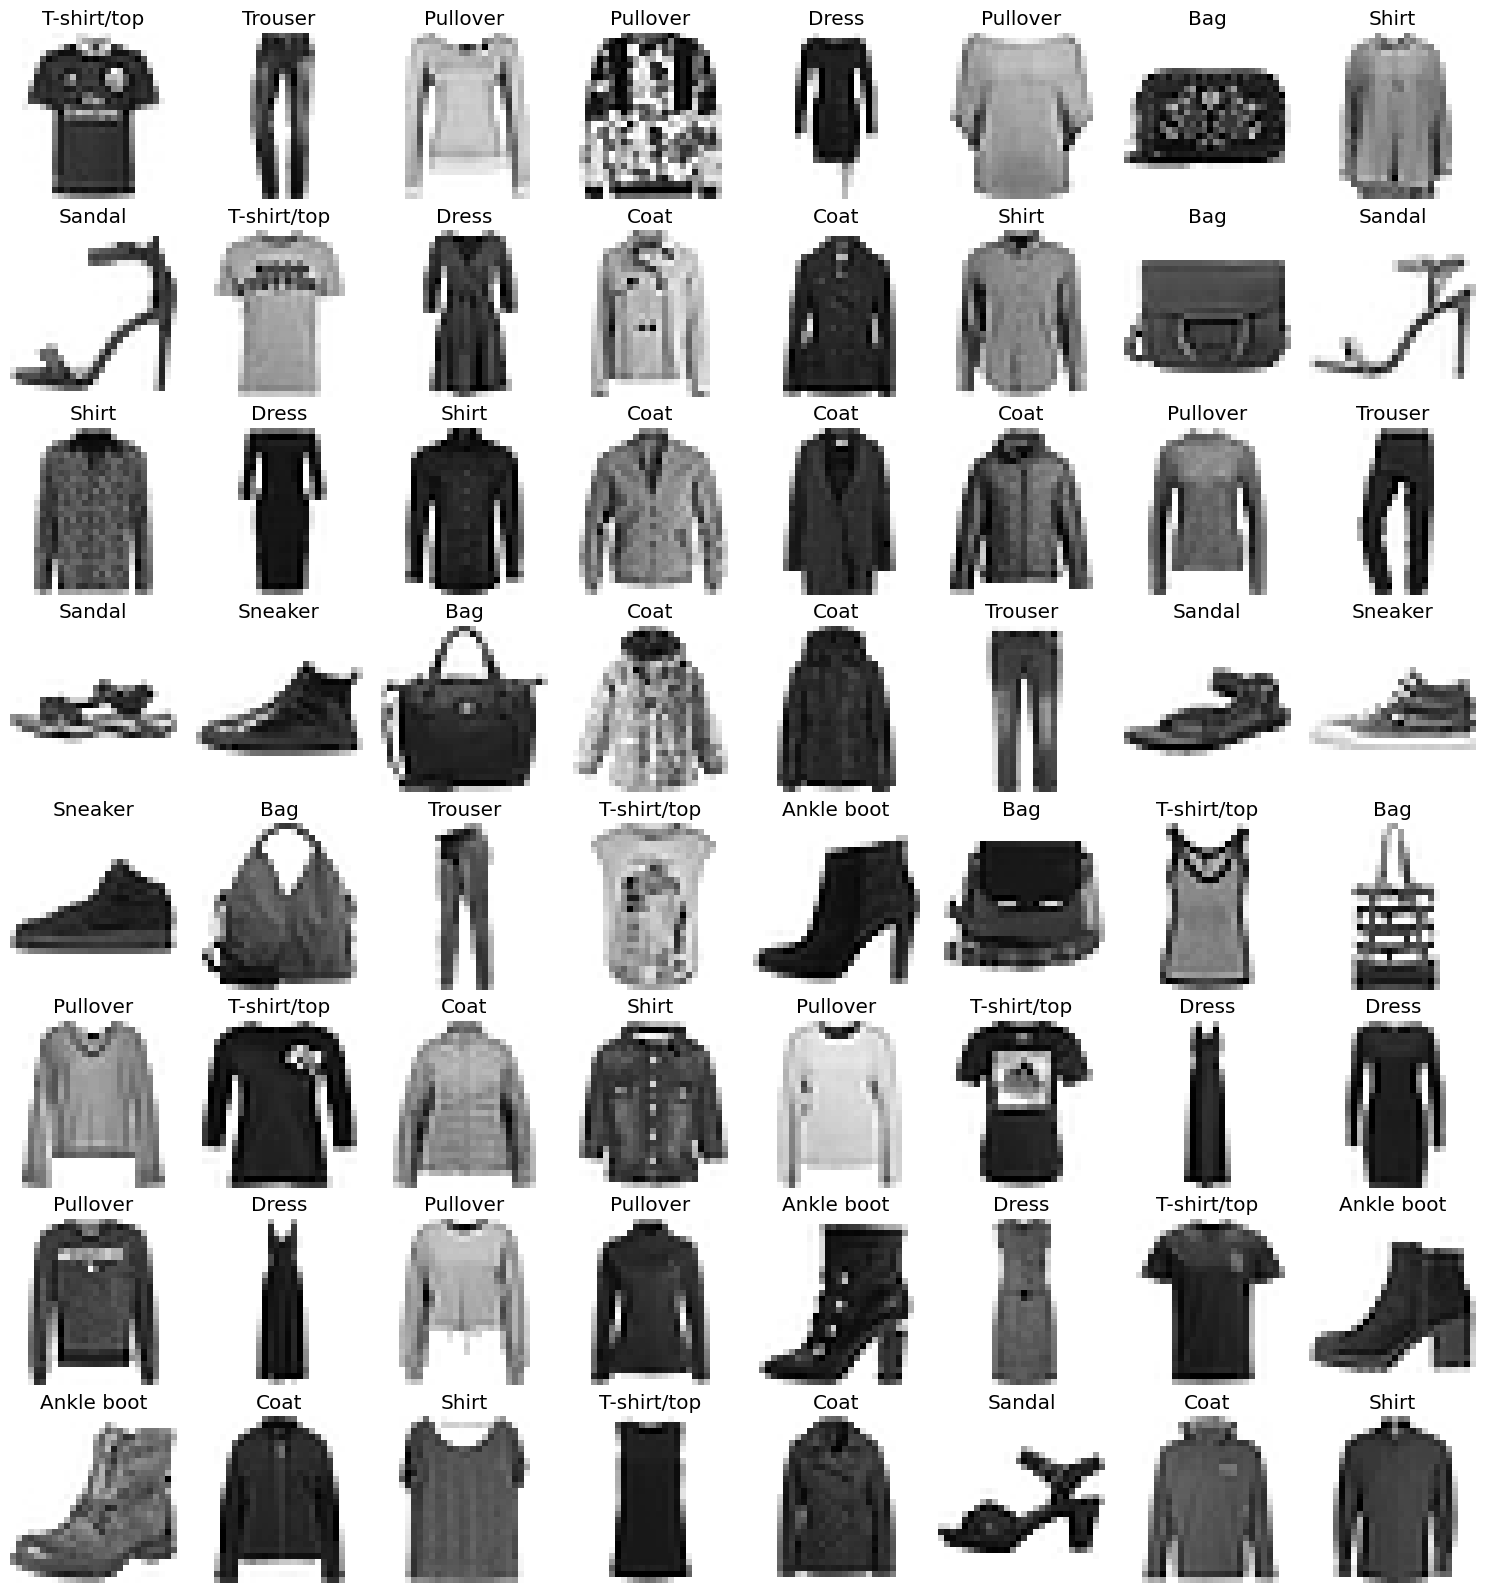

In [14]:
show_samples(test_loader,class_labels=class_names)

# Define Model

In [15]:
class CNNFashion(nn.Module):
    def __init__(self,num_classes = 10):
        super(CNNFashion,self).__init__()
        dor1 = 0.1
        dor2 = 0.2
        dor3 =  0.3
        dor4 = 0.4

        
        # Set 1
        in_channels1 =1
        out_channels1 =32
        self.conv1 = nn.Conv2d(in_channels =in_channels1,
                               out_channels =out_channels1,
                               kernel_size = 3,
                               padding = "same")
        self.bn1 = nn.BatchNorm2d(out_channels1)
        self.relu1 = nn.ReLU()
        self.maxpool1 = nn.MaxPool2d(kernel_size=(2,2),stride=(2,2))
        self.do1 = nn.Dropout(p = dor1)

        # Set 2
        in_channels2 = out_channels1
        out_channels2 =64
        self.conv2 = nn.Conv2d(in_channels =in_channels2,
                               out_channels =out_channels2,
                               kernel_size = 3,)
        self.bn2 = nn.BatchNorm2d(out_channels2)
        self.relu2 = nn.ReLU()
        self.maxpool2 = nn.MaxPool2d(kernel_size=(2,2),stride=(2,2))
        self.do2 = nn.Dropout(p = dor2)

        # Set 3
        in_channels3 = out_channels2
        out_channels3 =128
        self.conv3 = nn.Conv2d(in_channels =in_channels3,
                               out_channels =out_channels3,
                               kernel_size = 3,)
        self.bn3 = nn.BatchNorm2d(out_channels3)
        self.relu3 = nn.ReLU()
        self.do3 = nn.Dropout(p = dor3)

        self.fc_input_size = 128*4*4
        self.fc1 = nn.Linear(self.fc_input_size,128)
        self.bn4 = nn.BatchNorm1d(128)
        self.relu4 = nn.ReLU()
        self.do4 = nn.Dropout(p = dor4)

        self.fc2 = nn.Linear(128,num_classes)

    def forward(self,x):
        # Set 1
        x = self.do1(self.maxpool1(self.relu1(self.bn1(self.conv1(x)))))
        # Set 2
        x = self.do2(self.maxpool2(self.relu2(self.bn2(self.conv2(x)))))
        # Set 3
        x = self.do3(self.relu3(self.bn3(self.conv3(x))))

        #Flatten
        x = torch.flatten(x,start_dim =1)

        #fc1
        x = self.do4(self.relu4(self.bn4(self.fc1(x))))
        return self.fc2(x)

model = CNNFashion(num_classes = 10).to(device = device)
print(model)


CNNFashion(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (do1): Dropout(p=0.1, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (do2): Dropout(p=0.2, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu3): ReLU()
  (do3): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (bn4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=

In [16]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=ALPHA)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer,
                                                       mode = "min",
                                                       factor = LR_FACTOR,
                                                       patience = LR_PATIENCE)


### Code for training cycle:

In [17]:
loss = []
accuracy = []
val_loss = []
val_accuracy = []

In [18]:
def train_model(model,
                train_loader,
                test_loader,
                loss_fn = loss_fn,
                optimizer = optimizer,
                scheduler = scheduler,
                device = device):
    for epoch in tqdm(range(25)):
        epoch_loss = 0
        epoch_acc = 0
        epoch_t_loss = 0
        epoch_t_acc = 0
        model.train()
        for batch_idx,(train_X,train_y) in tqdm(enumerate(train_loader)):
                train_x,train_y = train_X.to(device), train_y.to(device)
                predict_prob = model(train_X)
                batch_loss = loss_fn(predict_prob, train_y)
                epoch_loss += (batch_loss - epoch_loss)/(batch_idx +1)
                optimizer.zero_grad()
                batch_loss.backward()
                optimizer.step()
                _,y_preds = torch.max(predict_prob,1)
                batch_acc = accuracy_score(train_y.cpu().numpy(),
                                        y_preds.data.cpu()) 
                epoch_acc += (batch_acc - epoch_acc) / (batch_idx + 1)

        with torch.inference_mode():
            model.eval()
            for batch_idx,(test_X,test_y) in enumerate(test_loader):  
                    test_X,test_y = test_X.to(device), test_y.to(device)
                    predict_prob_test = model(test_X)
                    batch_t_loss = loss_fn(predict_prob_test,test_y)
                    epoch_t_loss += (batch_t_loss - epoch_t_loss)/(batch_idx+1)
                    _,y_t_preds = torch.max(predict_prob_test,1)
                    batch_t_acc = accuracy_score(test_y.cpu().numpy(),y_t_preds.data.cpu())
                    epoch_t_acc += (batch_t_acc - epoch_t_acc)/(batch_idx+1)

        print("epoch:",epoch,"loss =", epoch_loss.item(), "accuracy =",epoch_acc, "\t\t\t", "val_loss",epoch_t_loss.item(), "val_accuracy", epoch_t_acc)
        loss.append(epoch_loss.item())
        accuracy.append(epoch_acc)
        val_loss.append(epoch_t_loss.item())
        val_accuracy.append(epoch_t_acc)


In [19]:
train_model(model,train_loader,
            test_loader,
            loss_fn = loss_fn,
            optimizer = optimizer,
            scheduler = scheduler,
            device = device)

  0%|          | 0/25 [00:00<?, ?it/s]

0it [00:00, ?it/s]

epoch: 0 loss = 0.460925430059433 accuracy = 0.8390525053304894 			 val_loss 0.28689008951187134 val_accuracy 0.8979896496815286


0it [00:00, ?it/s]

epoch: 1 loss = 0.32021528482437134 accuracy = 0.8842617270788914 			 val_loss 0.24331335723400116 val_accuracy 0.9099323248407647


...

epoch: 22 loss = 0.15719254314899445 accuracy = 0.9421974946695083 			 val_loss 0.16386622190475464 val_accuracy 0.940684713375796


0it [00:00, ?it/s]

epoch: 23 loss = 0.1531175822019577 accuracy = 0.9424140458422169 			 val_loss 0.17089422047138214 val_accuracy 0.9377985668789806


0it [00:00, ?it/s]

epoch: 24 loss = 0.15277953445911407 accuracy = 0.942730543710022 			 val_loss 0.16737057268619537 val_accuracy 0.9397890127388535


In [20]:
import numpy as np
accuracy = np.array(accuracy)
loss = np.array(loss)
val_accuracy = np.array(val_accuracy)
val_loss = np.array(val_loss)

df_metric = pd.DataFrame({"Epochs" : np.arange(EPOCHS),
                          "Loss":loss,
                          "Validation loss": val_loss,
                          "Accuracy":accuracy,
                          "Validation Accuracy": val_accuracy,
                          })

ValueError: All arrays must be of the same length

In [ ]:
def fn_plot_torch_hist(hist_df: pd.DataFrame):
    """
    Plots the training and validation loss and accuracy curves from a PyTorch training history DataFrame.
    
    Args:
        hist_df (pd.DataFrame): A pandas DataFrame with five columns:
                                - First column: epoch (x-axis values)
                                - Second & third columns: losses (train & validation)
                                - Fourth & fifth columns: accuracies (train & validation)
    
    Returns:
        None: Displays the matplotlib plots.
    """
    # Ensure the DataFrame has exactly five columns
    if hist_df.shape[1] < 5:
        raise ValueError("The DataFrame must have atleast five columns: epoch, train_loss, val_loss, train_acc, val_acc.")
    
    # Extract column names for better readability and maintainability
    #epoch loss	           test_loss	 acc	        test_acc
    x_col, train_loss_col, val_loss_col, train_acc_col, val_acc_col, *cols= hist_df.columns
    
    # Instantiate figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    facecolor = 'cyan'  # Text box background color
    fontsize = 12  # Font size for annotations
    props = dict(boxstyle='round', facecolor=facecolor, alpha=0.5)  # Text box properties

    # First subplot: Loss curves
    ax = axes[0]
    hist_df.plot(x=x_col, y=[train_loss_col, val_loss_col], ax=ax)
    
    # Annotation: Final losses
    final_losses_text = f"Loss:\nTrain: {hist_df[train_loss_col].iloc[-1]:.4f}\nVal: {hist_df[val_loss_col].iloc[-1]:.4f}"
    ax.text(0.3, 0.95, final_losses_text, transform=ax.transAxes, fontsize=fontsize, 
            verticalalignment='top', bbox=props)
    
    # Annotation: Minimum validation loss
    best_val_loss_idx = hist_df[val_loss_col].idxmin()
    best_val_loss_epoch = hist_df.loc[best_val_loss_idx, x_col]
    best_val_loss_value = hist_df.loc[best_val_loss_idx, val_loss_col]
    ax.annotate(f"Min: {best_val_loss_value:.4f}", 
                xy=(best_val_loss_epoch, best_val_loss_value), 
                xytext=(best_val_loss_epoch - 2, best_val_loss_value + 0.05),
                fontsize=fontsize, ha='right', va='bottom', bbox=props, 
                arrowprops=dict(facecolor=facecolor, shrink=0.05))
    ax.axvline(x=best_val_loss_epoch, color='green', linestyle='-.', lw=2)
    
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Loss Curves")
    ax.legend(loc='upper left')
    ax.grid(True)

    # Second subplot: Accuracy curves
    ax = axes[1]
    hist_df.plot(x=x_col, y=[train_acc_col, val_acc_col], ax=ax)
    
    # Annotation: Final accuracies
    final_acc_text = f"Accuracy:\nTrain: {hist_df[train_acc_col].iloc[-1]:.4f}\nVal: {hist_df[val_acc_col].iloc[-1]:.4f}"
    ax.text(0.3, 0.2, final_acc_text, transform=ax.transAxes, fontsize=fontsize, 
            verticalalignment='top', bbox=props)
    
    # Annotation: corresponding validation accuracy
    best_val_acc_epoch = hist_df.loc[best_val_loss_idx, x_col]
    best_val_acc_value = hist_df.loc[best_val_loss_idx, val_acc_col]
    ax.annotate(f"Max: {best_val_acc_value:.4f}", 
                xy=(best_val_acc_epoch, best_val_acc_value), 
                xytext=(best_val_acc_epoch - 2, best_val_acc_value - 0.05),
                fontsize=fontsize, ha='right', va='top', bbox=props, 
                arrowprops=dict(facecolor=facecolor, shrink=0.05))
    ax.axvline(x=best_val_acc_epoch, color='green', linestyle='-.', lw=2)
    
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_title("Accuracy Curves")
    ax.legend(loc='lower left')
    ax.grid(True)

    plt.tight_layout()
    plt.show()


In [ ]:
fn_plot_torch_hist(df_metric)

In [ ]:
y_true,y_pred = [],[]
model.eval()
acc = 0
with torch.inference_mode():
    for batch_idx, (train_X,train_y) in enumerate(train_loader):
        train_X = train_X.to(device)
        pred = model(train_X)
        y_pred.extend(torch.argmax(pred,dim=1).cpu().numpy())
        y_true.extend(train_y)
    acc = accuracy_score(y_true,y_pred)

In [ ]:
print("Train accuracy: ",acc)

In [ ]:
y_true,y_pred = [],[]
model.eval()
test_acc = 0
with torch.inference_mode():
    for batch_idx, (test_X,test_y) in enumerate(test_loader):
        test_X = test_X.to(device)
        pred = model(test_X)
        y_pred.extend(torch.argmax(pred,dim=1).cpu().numpy())
        y_true.extend(test_y)
    test_acc = accuracy_score(y_true,y_pred)

In [ ]:
print("Test accuracy: ",test_acc)

In [ ]:
num_samples =50
cols =10
rows = num_samples //cols
fig,axes = plt.subplots(rows)
axes = axes.ravel()

for i in range(min(num_samples,len(misclassified_images))):
    img = misclassified_images[i].sqeeze().numpy()

    color = "red" if misclassified_true[i] != misclassified_pred[i] else "cyan"
    props = dict(boxstyle = "round",
                facecolor = color,
                alpha=0.5)
    axes[i].imshow(img,cmap = plt.cm.binary)
    axes[i].set_title(class_names[misclassified_true[i].item()],fontsize = 10)
    axes[i].text(0.1,0.95,class_names[misclassified_pred[i].item()],
    transform = axes[i].transAxes,fontsize =10,)